In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
housing = pd.read_csv("../data/cleaned/housing_master_updated.csv")

**Forecast (2025 price = current price(2024) + average yearly growth price)**

In [37]:
forecast_data = housing[[
    "country",
    "year",
    "nominal_house_price_index"
]].copy()

# Drop rows ONLY if price is missing
forecast_data = forecast_data.dropna(subset=["nominal_house_price_index"])

In [38]:
forecast_data["country"].unique()

<StringArray>
[    'Austria',      'France',     'Germany',       'Italy', 'Netherlands',
      'Poland',    'Portugal',       'Spain',      'Sweden']
Length: 9, dtype: str

In [39]:
def calculate_cagr_safe(df):
    results = []
    
    for country in df["country"].unique():
        sub = df[df["country"] == country].sort_values("year")
        
        # Skip if too little data
        if len(sub) < 2:
            continue
        
        start = sub["nominal_house_price_index"].iloc[0]
        end = sub["nominal_house_price_index"].iloc[-1]
        years = sub["year"].iloc[-1] - sub["year"].iloc[0]
        
        if years == 0 or start == 0:
            continue
        
        cagr = (end / start) ** (1 / years) - 1
        
        results.append({
            "country": country,
            "cagr": cagr
        })
    
    return pd.DataFrame(results)



In [40]:
cagr_df = calculate_cagr_safe(forecast_data)
cagr_df

,country,cagr
0,Austria,0.054741
1,France,0.015687
2,Germany,0.040749
3,Italy,-0.001081
4,Netherlands,0.041993
5,Poland,0.049135
6,Portugal,0.061780
7,Spain,0.012563
8,Sweden,0.042250


In [41]:
latest_prices = (
    forecast_data
    .sort_values("year")
    .groupby("country")
    .tail(1)
)

latest_prices = latest_prices[["country", "nominal_house_price_index"]]

In [42]:
forecast = latest_prices.merge(cagr_df, on="country", how="left")

In [43]:
# Fill missing CAGR with average CAGR
average_cagr = cagr_df["cagr"].mean()

forecast["cagr"] = forecast["cagr"].fillna(average_cagr)

In [44]:
forecast["forecast_2025_price"] = (
    forecast["nominal_house_price_index"] * (1 + forecast["cagr"])
)

In [45]:
print("Number of countries:", forecast["country"].nunique())
forecast

Number of countries: 9


,country,nominal_house_price_index,cagr,forecast_2025_price
0,Austria,163.060000,0.054741,171.986066
1,Sweden,132.017500,0.042250,137.595207
2,Poland,206.702500,0.049135,216.858878
3,Netherlands,198.199750,0.041993,206.522805
4,Spain,160.253599,0.012563,162.266830
5,Italy,116.200000,-0.001081,116.074426
6,Portugal,263.847500,0.061780,280.148105
7,France,127.025000,0.015687,129.017656
8,Germany,152.688382,0.040749,158.910355


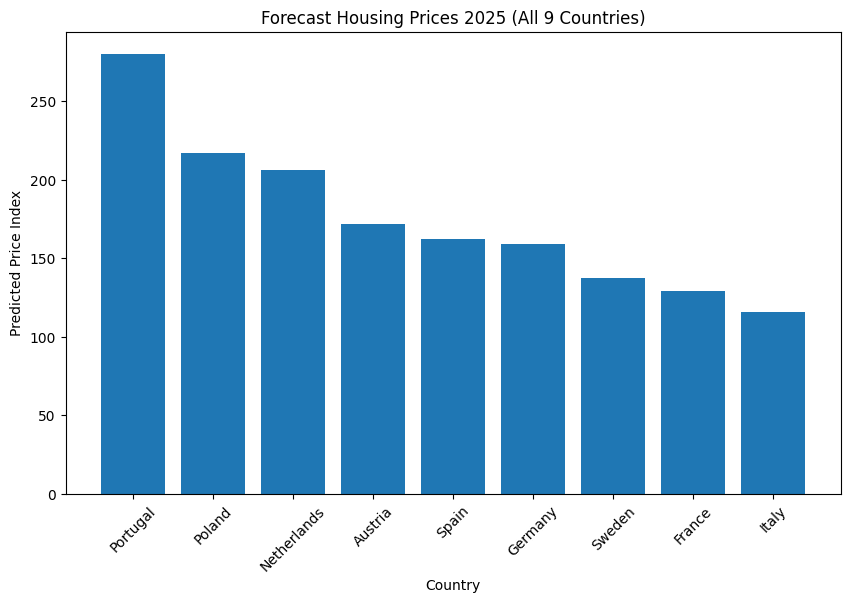

In [46]:
forecast = forecast.sort_values("forecast_2025_price", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(forecast["country"], forecast["forecast_2025_price"])

plt.xticks(rotation=45)
plt.title("Forecast Housing Prices 2025 (All 9 Countries)")
plt.xlabel("Country")
plt.ylabel("Predicted Price Index")

plt.show()

In [47]:
ranking = pd.read_csv("../data/cleaned/investment_ranking_updated.csv")

final_forecast_2025 = forecast.merge(ranking, on="country")

final_forecast_2025

,country,nominal_house_price_index,cagr,forecast_2025_price,year,nominal_price_total_growth_pct,rent_total_growth_pct,price_to_income_ratio,price_to_rent_ratio,average_annual_wage,household_disposable_income,interest_rate,population_growth,growth_score,rent_score,affordability_score,interest_score,demand_score,investment_score,recommendation
0,Portugal,263.847500,0.061780,280.148105,2024,109.058519,42.528023,147.263891,173.251483,23177.059,33735.060377,2.957500,1.162337,98.431266,43.612468,2.972009,77.224316,100.000000,65.508359,Attractive
1,Poland,206.702500,0.049135,216.858878,2024,95.722469,83.063269,102.752499,124.019024,91625.251,29833.094772,5.525000,-0.358698,86.964537,100.000000,0.000000,0.000000,0.000000,41.741134,High Risk / Low Priority
2,Netherlands,198.199750,0.041993,206.522805,2024,77.872483,43.273569,130.538403,161.189543,58248.347,41485.053617,2.620500,0.655122,71.616592,44.649578,32.300006,87.360477,66.653327,59.728802,Watchlist
3,Austria,163.060000,0.054741,171.986066,2024,110.882990,70.475455,114.681996,115.514314,56968.032,46831.235422,2.842708,0.538894,100.000000,82.489418,71.018447,80.676977,59.011924,79.605504,Strong Buy
4,Spain,160.253599,0.012563,162.266830,2024,19.098811,11.176375,115.697145,144.437446,33043.823,35161.929740,3.153796,1.007061,21.081254,0.000000,37.322898,71.320212,89.791426,41.391210,High Risk / Low Priority
5,Germany,152.688382,0.040749,158.910355,2024,76.445673,22.654972,107.844945,128.648436,50256.900,47685.379160,2.321084,0.275336,70.389778,15.967580,88.427903,96.366198,41.684357,61.268342,Attractive
6,Sweden,132.017500,0.042250,137.595207,2024,78.486446,32.024655,95.494507,110.812999,529659.000,35146.560577,2.200270,0.313943,72.144496,29.001503,60.591909,100.000000,44.222581,59.799323,Watchlist
7,France,127.025000,0.015687,129.017656,2024,25.503356,13.883960,93.403700,117.710993,44908.538,39420.801801,2.975517,0.263040,26.588071,3.766451,83.496594,76.682417,40.875980,43.777185,High Risk / Low Priority
8,Italy,116.200000,-0.001081,116.074426,2024,-5.419136,13.904428,87.042987,102.976149,33148.002,38593.144825,3.707417,-0.053433,0.000000,3.794925,100.000000,54.668600,20.069562,32.973187,High Risk / Low Priority


In [48]:
final_forecast_2025.to_csv("../data/cleaned/2025_investment_forecast.csv", index=False)